In [1]:
# Task 1 -Dataset Collection
import kagglehub
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [2]:
import os

os.listdir(path)

['one-indexed-files-notrash_val.txt',
 'one-indexed-files-notrash_train.txt',
 'Garbage classification',
 'garbage classification',
 'zero-indexed-files.txt',
 'one-indexed-files.txt',
 'one-indexed-files-notrash_test.txt']

Using Colab cache for faster access to the 'garbage-classification' dataset.
Dataset downloaded at: /kaggle/input/garbage-classification
Dataset classes: ['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Data preprocessing pipeline created successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 278s 4s/step - accuracy: 0.2935 - loss: 1.7249 - val_accuracy: 0.3400 - val_loss: 1.5907
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 286s 4s/step - accuracy: 0.4121 - loss: 1.4509 - val_accuracy: 0.3718 - val_loss: 1.4657
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.4684 - loss: 1.3078 - val_accuracy: 0.4016 - val_loss: 1.4616
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.5153 - loss: 1.2493 - val_accuracy: 0.4771 - val_loss: 1.3634
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 284s 4s/step - accuracy: 0.5252 - loss: 1.2470 - val_accuracy: 0.4732 - val_loss: 1.3326
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 263s 4s/step - accuracy: 0.5623 - loss: 1.1481 - val_accuracy: 0.4751 - val_loss: 1.3655
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 274s 4s/step - accuracy: 0.5608 - loss: 1.1389 - val_accuracy: 0.4791 - val_loss: 1.2702
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.5642 - loss: 1.1276 - val_accuracy: 0.4891 - v

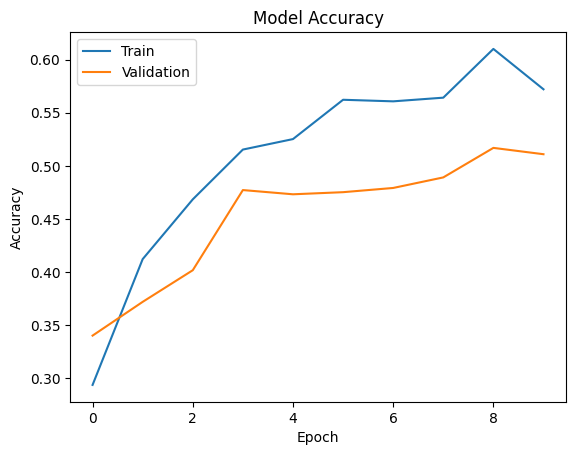

Model saved successfully!
Place a test image named 'test.jpg' in the project folder to test prediction.


In [3]:
# Task2  – Data Preprocessing

import kagglehub
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Dataset downloaded at:", path)

# Dataset folder
dataset_path = os.path.join(path, "Garbage classification", "Garbage classification")
print("Dataset classes:", os.listdir(dataset_path))

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    shear_range=0.2,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Data preprocessing pipeline created successfully!")

# Task3 - CNN Model Development
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(6,activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()

model.save("garbage_classifier_model.h5")

print("Model saved successfully!")

img_path = "test.jpg"

if os.path.exists(img_path):

    img = image.load_img(img_path,target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array,axis=0)
    img_array = img_array/255.0

    prediction = model.predict(img_array)

    classes = list(train_generator.class_indices.keys())

    print("Predicted class:", classes[np.argmax(prediction)])

else:
    print("Place a test image named 'test.jpg' in the project folder to test prediction.")

16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
Predictions generated successfully!

Model Accuracy: 0.20874751491053678


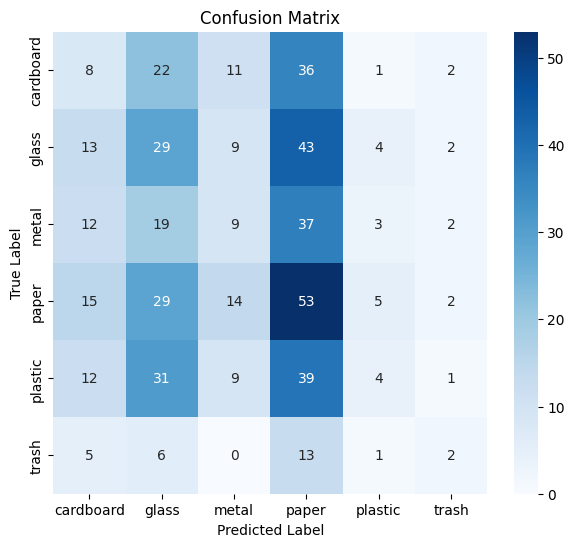


Sample Test Predictions:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


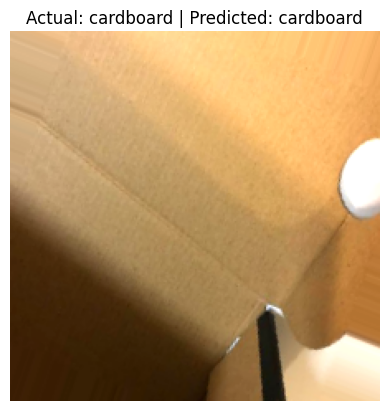

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


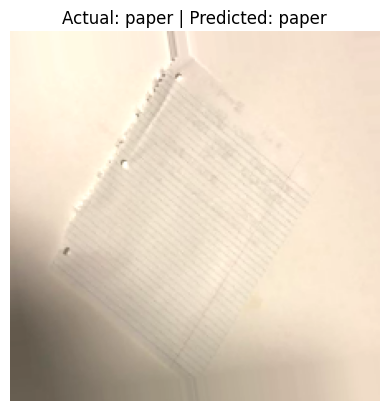

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


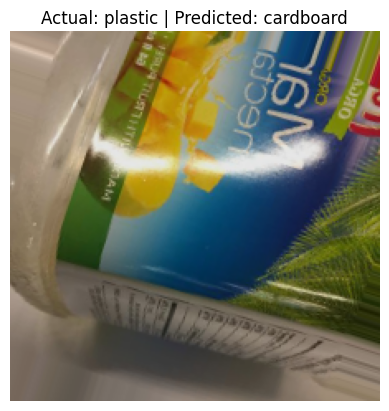

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


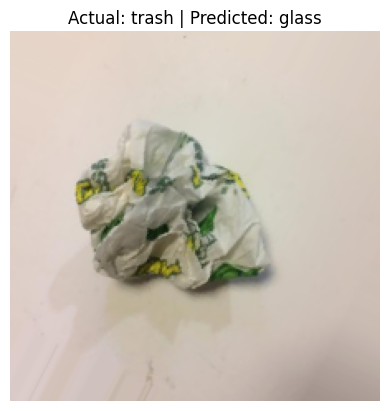

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


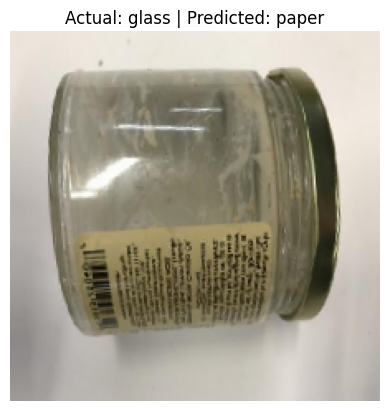

In [4]:
# ===============================
# Task 4 – Model Evaluation
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Reset generator before prediction
validation_generator.reset()

# Get predictions
predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = validation_generator.classes

# Class names
class_names = list(validation_generator.class_indices.keys())

print("Predictions generated successfully!")


accuracy = accuracy_score(true_classes, predicted_classes)
print("\nModel Accuracy:", accuracy)


cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nSample Test Predictions:\n")

images, labels = next(validation_generator)

for i in range(5):

    img = images[i]
    actual_label = class_names[np.argmax(labels[i])]

    img_array = np.expand_dims(img, axis=0)

    prediction = model.predict(img_array)
    predicted_label = class_names[np.argmax(prediction)]

    plt.imshow(img)
    plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}")
    plt.axis("off")
    plt.show()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.5558 - loss: 1.1474 - val_accuracy: 0.6521 - val_loss: 0.8247
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7189 - loss: 0.7493 - val_accuracy: 0.6600 - val_loss: 0.7783
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.7648 - loss: 0.6455 - val_accuracy: 0.6899 - val_loss: 0.7934
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7930 - loss: 0.5607 - val_accuracy: 0.7356 - val_loss: 0.6890
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.8068 - loss: 0.5267 - val_accuracy: 0.7256 - val_loss: 0.6769
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.8216 - loss: 0.4976 - val_accuracy: 0.7594 - val_loss: 0.6385
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8404 - loss: 0.4394 - val_accuracy: 0.7614 - val_loss: 0.6612
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.8473 - loss: 0.4155 - val_accuracy: 0.7475 - v

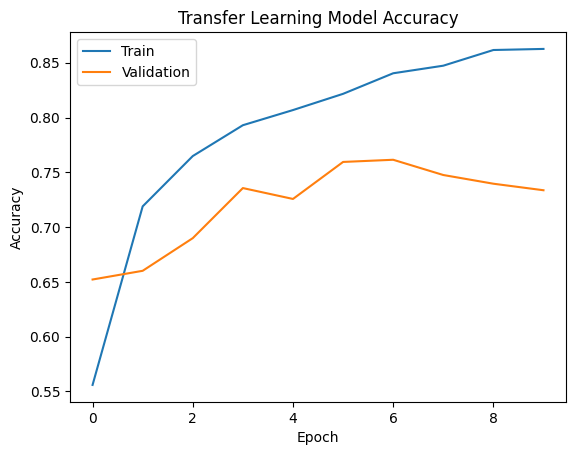

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# IMPORTANT → dataset has 6 classes
predictions = Dense(6, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions)


transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

history_transfer = transfer_model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])

plt.title("Transfer Learning Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()